In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import itertools
from itertools import combinations, permutations
from typing import Dict, Tuple, List
import random
import pulp
import time
import math

In [39]:
import pulp
from pulp import LpProblem, LpVariable, lpSum, LpMaximize, LpBinary, LpStatus, value
from collections import defaultdict

def solver_for_opt_network(network):
    
    n = network.n_players
    allowed_graph = network.allowed_graph
    neighbor_limits = network.neighbor_limits
    payoffs = network.payoffs
    model = LpProblem("BIP", LpMaximize)

    x = {}
    for (i, j) in allowed_graph:
        x[i, j] = LpVariable(f"x_{i}_{j}", cat=LpBinary)
    
    model += lpSum(payoffs[(i, j)] * x[i, j] for (i, j) in allowed_graph)
    
    for i in range(1, n+1):
        model += lpSum(x[min(i, j), max(i, j)] for j in range(1, n+1) if (min(i, j), max(i, j)) in allowed_graph) <= neighbor_limits[i]

    print(model)

    model.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=100, presolve=True))
    
    opt_edges = []
    opt_neighbors = {i: [] for i in range(1, n + 1)}
    print("Ответ:")
    for (i, j) in allowed_graph:
        print(f"x_{i}_{j} = {value(x[i, j])}, ", end='')
        if value(x[i ,j]) == 1:
            opt_edges.append((i , j))
            opt_neighbors[i].append(j)
            opt_neighbors[j].append(i)

    print(f"v(N) = {value(model.objective)}.")
    if model.status == 1:
        return {
            'opt_value': value(model.objective),
            'opt_edges': opt_edges,
            'neighbors_dict': dict(sorted(opt_neighbors.items()))
        }
    
    return "Error"

In [40]:
class CreateNetwork:
    def __init__(self, n: int, bimatrix_games: Dict[Tuple[int, int], Tuple[List[List[int]], List[List[int]]]], 
                 neighbor_limits: Dict[int, int], allowed_neighbors: Dict[int, List[int]]):
        self.n_players = n

        self.allowed_neighbors = allowed_neighbors
        self.neighbor_limits = neighbor_limits

        self.bimatrix_games = bimatrix_games

        self.allowed_graph = set()
 
        self.graph = nx.Graph()
        self.graph.add_nodes_from(range(1, self.n_players+1))

        self.payoffs = {}
        self.total_weight = 0

        self.precompute_weights()

        self.opt_value, self.opt_edges, self.opt_neighbors = solver_for_opt_network(self).values()

    def find_max_sum(self, a, b):
        a = np.array(a)
        b = np.array(b)
        return np.max(a + b.T)

    def precompute_weights(self) -> None: 
        for (i, j), (A, B) in self.bimatrix_games.items():
            if j in self.allowed_neighbors[i] and i in self.allowed_neighbors[j]:
                payoff = self.find_max_sum(A, B)
                self.payoffs[(i, j)] = payoff

                self.allowed_graph.add((i, j))
        print(f"g_allowed = {list(self.payoffs.keys())}")

    def max_min(self, matrix) -> int:
        rows_min = []
        for s in range(len(matrix)):
            rows_min.append(min(matrix[s]))
        return max(rows_min)

    def find_v(self, coalition):
        v = 0
        if len(coalition) == 0:
            return 0
        for i in coalition:
            for j in self.opt_neighbors[i]:
                if j in coalition:
                    if i < j:
                        max_sum = self.find_max_sum(
                            self.bimatrix_games[(i, j)][0], 
                            self.bimatrix_games[(i, j)][1]  
                        )
                        v = v + float(max_sum)
                else:
                    if i < j:
                        v += self.max_min(self.bimatrix_games[(i,j)][0])
                    else:
                        v += self.max_min(self.bimatrix_games[(j, i)][1])
        return v           
    
    def find_vector_shapley(self, n):
        shapley = np.zeros(n)
        players = range(1, n+1)
        all_coalitions = [comb for i in range(1, n + 1) for comb in itertools.combinations(players, i)]
        for coalition in all_coalitions:
            for i in coalition:
                s = len(coalition)
                coalition_without_i = tuple(x for x in coalition if x != i)
                shapley[i-1] += ( ( math.factorial(s - 1)*math.factorial(n - s) ) / math.factorial(n) ) * ( self.find_v(coalition) - self.find_v(coalition_without_i) )   
        return shapley

    def drawing(self, edges) -> None:

        self.graph.clear_edges()
        self.graph.add_edges_from(edges)

        params = optimized_graph_parameters(self.graph)

        pos = params['pos']
        plt.figure(figsize=params['figsize'])

        nx.draw_networkx_nodes(self.graph, pos, node_size=params['node_size'], node_color='lightblue', alpha=params['node_alpha'])
        
        nx.draw_networkx_labels(self.graph, pos, font_size=params['font_size'])
  
        nx.draw_networkx_edges(self.graph, pos, width=params['edge_width'], edge_color='gray', alpha=params['edge_alpha'])

        plt.axis("off")
        plt.show()


In [41]:
def optimized_graph_parameters(G, scale_multiplier=1.5): # параметры рисунка графа для различного числа узлов
    n = G.number_of_nodes()
    
    if n <= 5:
        k_val = 0.3
        iterations = 15
        scale = 0.8
        figsize = (8, 6)
        node_size = 800
        edge_width = 2.0
        font_size = 12
        node_alpha = 0.9
        edge_alpha = 0.8
    elif n <= 15:
        k_val = 0.6
        iterations = 25
        scale = 1.0
        figsize = (10, 8)
        node_size = 600
        edge_width = 1.5
        font_size = 11
        node_alpha = 0.85
        edge_alpha = 0.7
    elif n <= 30:
        k_val = 0.9
        iterations = 35
        scale = 1.3
        figsize = (12, 10)
        node_size = 400
        edge_width = 1.2
        font_size = 10
        node_alpha = 0.8
        edge_alpha = 0.6
    elif n <= 60:
        k_val = 1.2
        iterations = 50
        scale = 1.6
        figsize = (14, 12)
        node_size = 300
        edge_width = 1.0
        font_size = 9
        node_alpha = 0.75
        edge_alpha = 0.5
    elif n <= 90:
        k_val = 1.4
        iterations = 70
        scale = 1.8
        figsize = (16, 14)
        node_size = 250
        edge_width = 0.8
        font_size = 8
        node_alpha = 0.7
        edge_alpha = 0.45
    elif n <= 120:
        k_val = 1.6
        iterations = 90
        scale = 2.0
        figsize = (18, 16)
        node_size = 200
        edge_width = 0.7
        font_size = 7
        node_alpha = 0.65
        edge_alpha = 0.4
    elif n <= 160:
        k_val = 1.8
        iterations = 110
        scale = 2.2
        figsize = (20, 18)
        node_size = 150
        edge_width = 0.6
        font_size = 6
        node_alpha = 0.6
        edge_alpha = 0.35
    elif n <= 200:
        k_val = 2.0
        iterations = 130
        scale = 2.4
        figsize = (22, 20)
        node_size = 120
        edge_width = 0.5
        font_size = 5
        node_alpha = 0.55
        edge_alpha = 0.3
    else:
        k_val = 2.5
        iterations = 150
        scale = 2.8
        figsize = (24, 22)
        node_size = 100
        edge_width = 0.4
        font_size = 4
        node_alpha = 0.5
        edge_alpha = 0.25
        
    pos = nx.spring_layout(G,
        k=k_val * scale_multiplier,
        iterations=iterations,
        threshold=1e-4,
        scale=scale * scale_multiplier,
        seed=42
    )

    return {
        'pos': pos,
        'figsize': figsize,
        'node_size': node_size,
        'edge_width': edge_width,
        'font_size': font_size,
        'node_alpha': node_alpha,
        'edge_alpha': edge_alpha
    }

In [46]:
def сreate_two_constraints(n):
    allowed_neighbors={}
    neighbor_limits={}
    
    for key in range(1, n + 1):
        neighbor_limits[key]=random.randint(0, n - 1)
        
        possible_values = [i for i in range(1, n + 1) if i != key]
        list_size = random.randint(0, n - 1)
        random_values = random.sample(possible_values, list_size)
        random_values.sort()
        allowed_neighbors[key] = random_values
        
    return allowed_neighbors, neighbor_limits  

In [47]:
def сreate_bimatrix_games(n, m_strategy, k_strategy, lower_limit: int, upper_limit: int):
    pairs = list(combinations(range(1, n+1), 2))
    bimatrix_games = {}
        
    for pair in pairs:
        key = pair
        payoff1 = np.random.randint(lower_limit, upper_limit, (m_strategy, k_strategy)).tolist()
        payoff2 = np.random.randint(lower_limit, upper_limit, (k_strategy, m_strategy)).tolist()
        bimatrix_games[key] = (payoff1, payoff2)
    return bimatrix_games

In [48]:
def print_dict_matrices_with_names(dictionary, m, k) -> None: # красивый вывод биматричных игр
    biggest_len = max(m ,k)
    for key, matrices in dictionary.items():
    
        name1 = f"A{key}"
        name2 = f"A{key[::-1]}"
        
        for i in range(biggest_len):
            if m == biggest_len:
                if i == m // 2:
                    print(f"{name1} = ", end='')
                    print(*matrices[0][i], end='  ')
                    if i < k:
                        if i == k // 2:
                            print(f"{name2} = ", end='')
                            print(*matrices[1][i])
                        else:
                            print(' '*(len(name2)+2), *matrices[1][i]) 
                    else:
                        print()
                else:
                    print(' '*(len(name1)+2), *matrices[0][i], end = '  ')
                    if i < k:
                        if i == k // 2:
                            print(f"{name2} = ", end='')
                            print(*matrices[1][i])
                        else:
                            print(' '*(len(name2)+2), *matrices[1][i]) 
                    else:
                        print()
            else:
                if i < m:
                    if i == m // 2:
                        print(f"{name1} = ", end='')
                        print(*matrices[0][i], end='  ')
                    else:
                        print(' '*(len(name1)+2), *matrices[0][i], end = '  ')
                    if i == k // 2:
                        print(f"{name2} = ", end='')
                        print(*matrices[1][i])
                    else:
                        print(' '*(len(name2)+2), *matrices[1][i])                             
                else:
                    if i == k // 2:
                        print(' '*(len(name1)+2*k+3), f"{name2} = ", end = '')
                        print(*matrices[1][i])
                    else:
                        print(' '*(len(name1)+len(name2)+2*k+6), *matrices[1][i])
                
        print()

Множества допустимых игроков
{1: [2, 4, 5, 6, 8, 9], 2: [1, 3, 4, 6, 8], 3: [1, 4, 8, 9], 4: [1, 2, 5, 7, 9, 10], 5: [2, 3, 4, 7], 6: [7, 9], 7: [8], 8: [1, 3, 9], 9: [2, 6], 10: [2, 3, 4, 5, 6, 7]} 

Максимальные количества связей:
{1: 4, 2: 2, 3: 8, 4: 5, 5: 2, 6: 6, 7: 6, 8: 5, 9: 5, 10: 4} 

Биматричные игры:
          8 7            8 5 3
A(1, 2) = 5 8  A(2, 1) = 3 1 2
          2 6  

          1 4            4 5 7
A(1, 3) = 7 9  A(3, 1) = 1 9 6
          5 4  

          5 4            4 3 8
A(1, 4) = 3 3  A(4, 1) = 9 5 3
          3 3  

          3 1            6 9 9
A(1, 5) = 1 7  A(5, 1) = 6 2 7
          8 1  

          2 5            8 6 7
A(1, 6) = 7 1  A(6, 1) = 7 2 6
          7 5  

          8 3            1 1 8
A(1, 7) = 1 2  A(7, 1) = 4 1 3
          5 2  

          3 2            1 9 1
A(1, 8) = 2 1  A(8, 1) = 7 1 6
          5 6  

          3 9            2 4 1
A(1, 9) = 1 9  A(9, 1) = 9 8 6
          5 8  

           1 6             1 5 4
A(1, 10) = 5 2  A(10

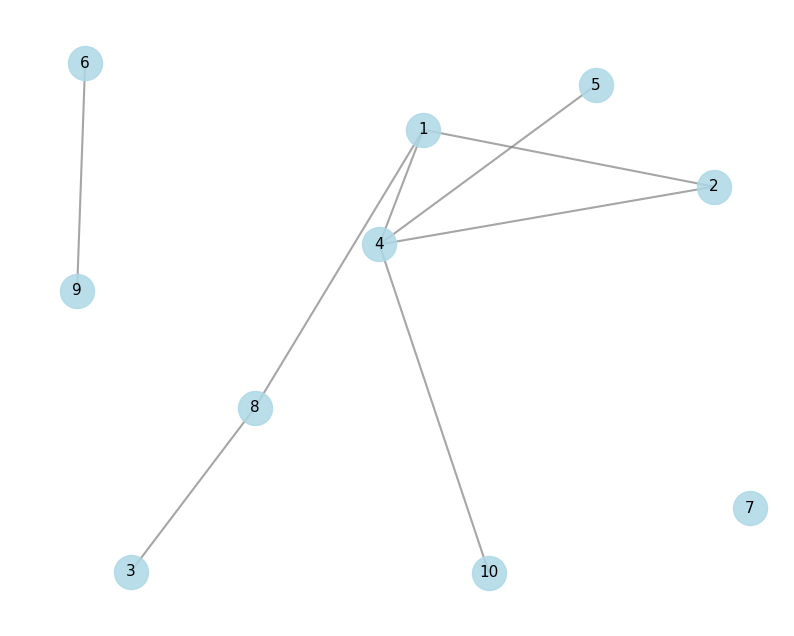

v((1,)) = 16
v((2,)) = 7
v((3,)) = 3
v((4,)) = 18
v((5,)) = 5
v((6,)) = 6
v((7,)) = 0
v((8,)) = 6
v((9,)) = 2
v((10,)) = 2
v((1, 2)) = 29.0
v((1, 3)) = 19
v((1, 4)) = 40.0
v((1, 5)) = 21
v((1, 6)) = 22
v((1, 7)) = 16
v((1, 8)) = 28.0
v((1, 9)) = 18
v((1, 10)) = 18
v((2, 3)) = 10
v((2, 4)) = 31.0
v((2, 5)) = 12
v((2, 6)) = 13
v((2, 7)) = 7
v((2, 8)) = 13
v((2, 9)) = 9
v((2, 10)) = 9
v((3, 4)) = 21
v((3, 5)) = 8
v((3, 6)) = 9
v((3, 7)) = 3
v((3, 8)) = 15.0
v((3, 9)) = 5
v((3, 10)) = 5
v((4, 5)) = 28.0
v((4, 6)) = 24
v((4, 7)) = 18
v((4, 8)) = 24
v((4, 9)) = 20
v((4, 10)) = 28.0
v((5, 6)) = 11
v((5, 7)) = 5
v((5, 8)) = 11
v((5, 9)) = 7
v((5, 10)) = 7
v((6, 7)) = 6
v((6, 8)) = 12
v((6, 9)) = 14.0
v((6, 10)) = 8
v((7, 8)) = 6
v((7, 9)) = 2
v((7, 10)) = 2
v((8, 9)) = 8
v((8, 10)) = 8
v((9, 10)) = 4
v((1, 2, 3)) = 32.0
v((1, 2, 4)) = 59.0
v((1, 2, 5)) = 34.0
v((1, 2, 6)) = 35.0
v((1, 2, 7)) = 29.0
v((1, 2, 8)) = 41.0
v((1, 2, 9)) = 31.0
v((1, 2, 10)) = 31.0
v((1, 3, 4)) = 43.0
v((1, 3, 5)) = 

In [50]:
def main():
    n = 10
    m = 3
    k = 2
  
    allowed_neighbors, neighbor_limits = сreate_two_constraints(n)

    bimatrix_games = сreate_bimatrix_games(n, m, k, 1, 10)

    print("Множества допустимых игроков")
    print(allowed_neighbors, "\n")

    print("Максимальные количества связей:")
    print(neighbor_limits, "\n")

    print("Биматричные игры:")
    print_dict_matrices_with_names(bimatrix_games, m, k)

    network = CreateNetwork(n, bimatrix_games, neighbor_limits, allowed_neighbors)

    print("Граф оптимальной сети:")
    network.drawing(network.opt_edges)

    players = range(1, n + 1)
    for length in range(1, n + 1): 
        for comb in combinations(players, length):
            v = network.find_v(comb)
            print(f"v({comb}) = {v}")

    print("Вектор Шепли:")
    print(network.find_vector_shapley(n))

if __name__ == "__main__":
    start_time = time.time()
    
    main()
        
    end_time = time.time()
    execution_time = end_time - start_time
    print(f"Программа работала: {execution_time:.4f} секунд") 